In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_cpu_use_thunk_runtime=false"
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import corner
import dill, os
from astropy.time import Time
from datetime import datetime

import jax.numpy as jnp
import jax
from jax import random, config
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, init_to_value, init_to_median
from numpyro import handlers
from jax import config
import arviz as az 
config.update('jax_enable_x64', True)

num_chains = 4
numpyro.set_host_device_count(num_chains)
print ('# jax device count:', jax.local_device_count())

# jax device count: 4


In [2]:
import jnkepler
print(jnkepler.__version__)
from numpyro_sample_orbits import model_relative_astrometry_radec_nocorr as model

0.2.4.post1.dev35


In [3]:
import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='times')
sns.set_palette('colorblind')
plt.rcParams["figure.figsize"] = (18,6)
from matplotlib import rc
rc('text', usetex=True)

## load simulated data

In [4]:
data = pd.read_csv("simulated_data.csv")
params = dict(np.load("simulated_data_params.npz", allow_pickle=True).items())

In [5]:
t, ra_obs, ra_err, dec_obs, dec_err = np.array(data[['epoch', 'raoff', 'raoff_err', 'decoff', 'decoff_err']]).T
mass_obs, mass_err = params['mass_obs_sim'], params['mass_err']
parallax_obs, parallax_err = params['parallax_obs_sim'], params['parallax_err']
print(mass_obs, parallax_obs)

1.54 24.44


## SVI Optimization and NUTS sampling

In [6]:
from numpyro_inferutils import find_map_svi
from numpyro_inferutils.fisher import information_from_model_independent_normal

def run_nuts(sample_method, ignore_obs=False, kernel_kwargs=None, run_kwargs=None, map_only=False,
             num_svi_steps=30000, svi_step_size=1e-2, num_warmup=7500, num_samples=7500):
    kernel_kwargs = {} if kernel_kwargs is None else kernel_kwargs
    run_kwargs = {} if run_kwargs is None else run_kwargs
    rng_key = random.PRNGKey(0)

    if ignore_obs:
        init_strategy = init_to_median()
    else:
        print("Running initial optimization...")
        p_map = find_map_svi(
            model,
            step_size=svi_step_size,
            num_steps=num_svi_steps,
            rng_key=rng_key,
            t=t,
            ra_obs=ra_obs, dec_obs=dec_obs, 
            ra_err=ra_err, dec_err=dec_err,
            mass_obs=mass_obs, mass_err=mass_err,
            parallax_obs=parallax_obs, parallax_err=parallax_err,
            sample_method=sample_method,
            p_initial={'logperiod': 13.}, # good initial guess is sometimes important
        )

        init_strategy = init_to_value(values=p_map)

        if map_only:
            return p_map

    kernel = numpyro.infer.NUTS(model, dense_mass=True, init_strategy=init_strategy, **kernel_kwargs)
    mcmc = numpyro.infer.MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

    print()
    print("Running MCMC...")
    mcmc.run(rng_key, t, ra_obs, ra_err, dec_obs, dec_err, 
             mass_obs, mass_err, parallax_obs, parallax_err,
             sample_method=sample_method, ignore_obs=ignore_obs, **run_kwargs,
             extra_fields=('potential_energy', 'num_steps', 'adapt_state'))
    mcmc.print_summary()
    idata = az.from_numpyro(mcmc)

    print("Number of steps:", np.median(idata.sample_stats['n_steps'], axis=1))

    return idata

In [7]:
# lower limit on period prior
pmin = (t[-1] - t[0]) * 5
print(pmin)

12705.0


## Sampling from posterior

In [8]:
kernel_kw = {'target_accept_prob': 0.99, 'max_tree_depth': 13}

In [9]:
idata_xv = run_nuts('xv', kernel_kwargs=kernel_kw, run_kwargs={'pmin': pmin})

Running initial optimization...


100%|██████████| 30000/30000 [00:07<00:00, 3909.51it/s, init loss: 258096.4313, avg. loss [28501-30000]: 99.1084] 



Running MCMC...


  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
            mass      1.54      0.14      1.54      1.32      1.77  16696.59      1.00
        parallax     24.44      0.05     24.44     24.36     24.51  25682.56      1.00
v_hat_dir_raw[0]      0.19      0.12      0.17      0.02      0.36   7518.19      1.00
v_hat_dir_raw[1]     -1.51      0.63     -1.45     -2.52     -0.50   8222.85      1.00
v_hat_dir_raw[2]     -0.01      0.52      0.00     -0.85      0.85   4848.64      1.00
           v_r_u      0.43      0.10      0.40      0.28      0.58   6004.89      1.00
x_hat_dir_raw[0]     -1.34      0.59     -1.28     -2.23     -0.36   8981.59      1.00
x_hat_dir_raw[1]     -0.38      0.16     -0.36     -0.63     -0.11   8977.93      1.00
x_hat_dir_raw[2]     -0.02      0.82     -0.04     -1.30      1.30   3136.02      1.00
           x_r_u      0.00      0.00      0.00      0.00      0.00   5625.93      1.00

Number of divergences: 98
Number of steps

In [11]:
idata_e = run_nuts('elements', kernel_kwargs=kernel_kw, run_kwargs={'pmin': pmin})

Running initial optimization...


100%|██████████| 30000/30000 [00:05<00:00, 5075.27it/s, init loss: 220819.4241, avg. loss [28501-30000]: 89.3391]



Running MCMC...


  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
       cosL      0.03      0.76      0.02     -1.28      1.30   2661.78      1.00
       cosi      0.83      0.09      0.83      0.71      1.00   2389.49      1.00
       cosm      0.33      0.91      0.32     -1.15      1.86   3168.05      1.00
       cosw     -0.01      1.07     -0.03     -1.71      1.74   2633.71      1.00
        ecc      0.18      0.14      0.16      0.00      0.34   2525.22      1.00
  logperiod     10.81      0.41     10.72     10.20     11.35   1971.70      1.00
       mass      1.55      0.14      1.55      1.32      1.77   6933.63      1.00
   parallax     24.44      0.05     24.44     24.37     24.51  15461.50      1.00
       sinL      0.02      1.20      0.05     -1.93      1.84   1285.71      1.00
       sinm      0.55      0.88      0.55     -0.88      2.02   2914.88      1.00
       sinw      0.02      0.93      0.03     -1.52      1.55   2950.02      1.00

Number of dive

In [ ]:
import pandas as pd

def get_diag(idata, var_names):
    summary = az.summary(idata, var_names=var_names)
    ret = summary[["r_hat", "ess_bulk", "ess_tail"]]
    ret['div'] = np.array(idata.sample_stats["diverging"]).sum()
    return ret

keys = ['logperiod', 'ecc', 'cosi', 'lnode', 'omega', 'M', 'mass', 'parallax']
labels = ['$\ln P$', '$e$', '$\cos i$', '$\Omega$', '$\omega$', '$M$', '$\mathcal{M}$', r'$\varpi$']
suffixes = ['elm', 'xv', 'xvp']
idatas = [idata_e, idata_xv]

out = []
for suffix, idata in zip(suffixes, idatas):
    out.append(get_diag(idata, keys).add_suffix(f"_{suffix}"))

df = pd.concat(out, axis=1)
df['imp_xv'] = df['ess_bulk_xv'] / df['ess_bulk_elm']

<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\O'
<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\O'
<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000gn/T/ipykernel_23040/1912151019.py:10: SyntaxWarning: invalid escape sequence '\l'
  labels = ['$\ln P$', '$e$', '$\cos i$', '$\Omega$', '$\omega$', '$M$', '$\mathcal{M}$', r'$\varpi$']
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000gn/T/ipykernel_23040/1912151019.py:10: SyntaxWarning: invalid escape sequence '\c'
  labels = ['$\ln P$', '$e$', '$\cos i$', '$\Omega$', '$\omega$', '$M$', '$\mathcal{M}$', r'$\varpi$']
/var/folders/qp/91qlh0v11sb02z

<>:11: SyntaxWarning: invalid escape sequence '\%'
<>:13: SyntaxWarning: invalid escape sequence '\%'
<>:11: SyntaxWarning: invalid escape sequence '\%'
<>:13: SyntaxWarning: invalid escape sequence '\%'
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000gn/T/ipykernel_23040/689094625.py:11: SyntaxWarning: invalid escape sequence '\%'
  label=f"Orbital elements\n(divergence: {df.div_elm[0]/30000.*100:.1f}\%)", color='C0', alpha=0.6)
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000gn/T/ipykernel_23040/689094625.py:13: SyntaxWarning: invalid escape sequence '\%'
  label=f"Cartesian vectors\n(divergence: {df[f'div_{key}'][0]/30000.*100:.1f}\%)", color='C1', alpha=0.6)
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000gn/T/ipykernel_23040/689094625.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"Orbital eleme

'\nplt.figure(figsize=(10,6))\nplt.bar(x - width/2, df["ess_tail_elm"].to_numpy() / run_elm / num_chains, width, \n        label=f"Orbital elements\n(divergence: {df.div_elm[0]})", color=\'C0\', alpha=0.6)\nplt.bar(x + width/2, df[f"ess_tail_{key}"].to_numpy() / run_xv / num_chains, width, \n        label=f"Cartesian vectors\n(divergence: {df[f\'div_{key}\'][0]})", color=\'C1\', alpha=0.6)\nplt.xticks(x, labels, ha="center")\nplt.ylabel("ESS tail\nper core-minute")\nplt.legend(loc=\'upper left\')\nplt.tight_layout()\nplt.show()\n'

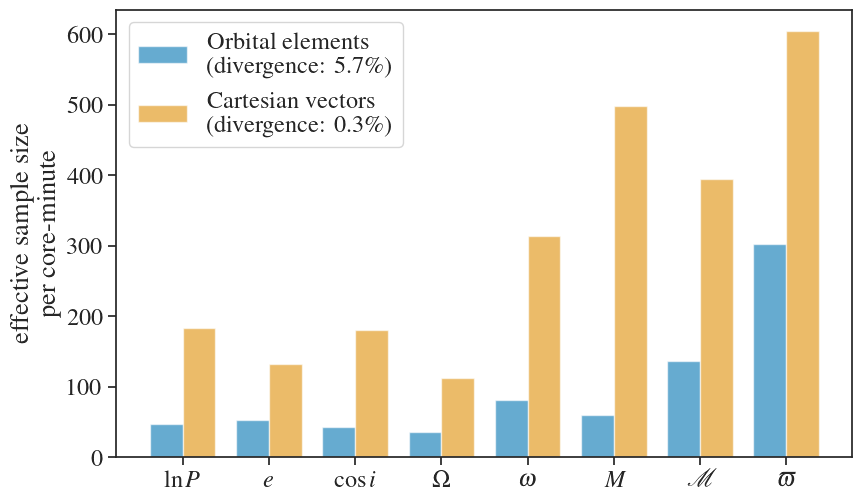

In [39]:
import matplotlib.pyplot as plt

run_elm, run_xv = 12+48/60., 10+37/60.
key = 'xv'
x = np.arange(len(labels))
width = 0.38

# ESS bulk
plt.figure(figsize=(10*0.9,6*0.9))
plt.bar(x - width/2, df["ess_bulk_elm"].to_numpy() / run_elm / num_chains, width, 
        label=f"Orbital elements\n(divergence: {df.div_elm[0]/30000.*100:.1f}\%)", color='C0', alpha=0.6)
plt.bar(x + width/2, df[f"ess_bulk_{key}"].to_numpy() / run_xv / num_chains, width, 
        label=f"Cartesian vectors\n(divergence: {df[f'div_{key}'][0]/30000.*100:.1f}\%)", color='C1', alpha=0.6)
plt.xticks(x, labels, ha="center")
plt.ylabel("effective sample size\nper core-minute")
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig("bulk_ess.png", dpi=400, bbox_inches="tight")

# ESS tail
'''
plt.figure(figsize=(10,6))
plt.bar(x - width/2, df["ess_tail_elm"].to_numpy() / run_elm / num_chains, width, 
        label=f"Orbital elements\n(divergence: {df.div_elm[0]})", color='C0', alpha=0.6)
plt.bar(x + width/2, df[f"ess_tail_{key}"].to_numpy() / run_xv / num_chains, width, 
        label=f"Cartesian vectors\n(divergence: {df[f'div_{key}'][0]})", color='C1', alpha=0.6)
plt.xticks(x, labels, ha="center")
plt.ylabel("ESS tail\nper core-minute")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
'''

## corner plots

In [22]:
keys = ['logperiod', 'ecc', 'cosi', 'lnode', 'omega', 'M', 'mass', 'parallax']
labels = ['$\ln P$ (days)', '$e$', '$\cos i$', '$\Omega$', '$\omega$', '$M$', '$\mathcal{M}$ ($M_\odot$)', r'$\varpi$ (mas)'] \
    + [f'$x_\mathrm{{ref,{i}}}$ (au)' for i in range(3)] + [f'$v_\mathrm{{ref,{i}}}$ (au/day)' for i in range(3)]

<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\o'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\O'
<>:2: SyntaxWarning: invalid escape sequence '\o'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000gn/T/ipykernel_23040/687348077.py:2: SyntaxWarning: invalid escape sequence '\l'
  labels = ['$\ln P$ (days)', '$e$', '$\cos i$', '$\Omega$', '$\omega$', '$M$', '$\mathcal{M}$ ($M_\odot$)', r'$\varpi$ (mas)'] \
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000g

In [ ]:
bins = 30
truth_vals = [params[key] for key in keys] + [None]*6
fig_ = corner.corner(idata_e, var_names=keys+['xref', 'vref'], show_titles=True, truths=truth_vals, truth_color="k",
                     title_fmt=None,
                     color='C0', hist_kwargs={'density': True}, labels=labels, bins=bins)
fig = corner.corner(idata_xvp, var_names=keys+['xref', 'vref'], fig=fig_, color='C1', hist_kwargs={'density': True}, labels=labels, bins=bins)

import matplotlib.lines as mlines
names = ["elements", "xv"]
names = ["Orbital elements", "Cartesian vectors"]
ndim = len(keys) + 6
handles = []
for i, name in enumerate(names):
    handles.append(mlines.Line2D([], [], color='C%d'%i, label=name))
plt.legend(handles=handles, bbox_to_anchor=(0.8, ndim), fontsize=55)
plt.savefig("corner.png", dpi=200, bbox_inches="tight");

## Posterior models

In [ ]:
def idata_to_numpyro_posterior_samples(idata, group="posterior"):
    post = getattr(idata, group)

    if "chain" in post.dims and "draw" in post.dims:
        stacked = post.stack(sample=("chain", "draw"))
        n_sample = stacked.sizes["sample"]
    else:
        stacked = post
        n_sample = next(iter(stacked.data_vars.values())).sizes.get("sample", None)

    samples = {}
    for name, da in stacked.data_vars.items():
        if "sample" in da.dims:
            da = da.transpose("sample", *[d for d in da.dims if d != "sample"])
            arr = np.asarray(da)
        else:
            arr0 = np.asarray(da)
            if n_sample is None:
                raise ValueError(f"Cannot infer n_sample for broadcasting {name}.")
            arr = np.broadcast_to(arr0, (n_sample,) + arr0.shape)

        samples[name] = arr

    return samples

def predictions(idata, sample_method):
    posterior_samples = idata_to_numpyro_posterior_samples(idata)
    posterior_samples.pop("x_ref", None)
    posterior_samples.pop("v_ref", None)

    pred_posterior = Predictive(model, posterior_samples=posterior_samples, 
                            return_sites=["x_mas", "y_mas"])
    p_mean = np.mean(posterior_samples['period'])
    t_pred = np.linspace(t[0]-5*p_mean, t[-1]+5*p_mean, 1000)
    err_dummy = jnp.ones_like(t_pred)
    post_models = pred_posterior(random.PRNGKey(0), t=t_pred, t_ref=t[0], 
                                 dec_obs=None, dec_err=None, ra_obs=None, ra_err=None, sample_method=sample_method,
                                 mass_obs=None, mass_err=None, parallax_obs=None, parallax_err=None,
                                 ignore_obs=True,
                                 pmin=pmin,
                                 )

    decmodels = post_models['x_mas']
    ramodels = post_models['y_mas']

    return ramodels, decmodels

In [25]:
ramodels, decmodels = predictions(idata_xv, 'xv')

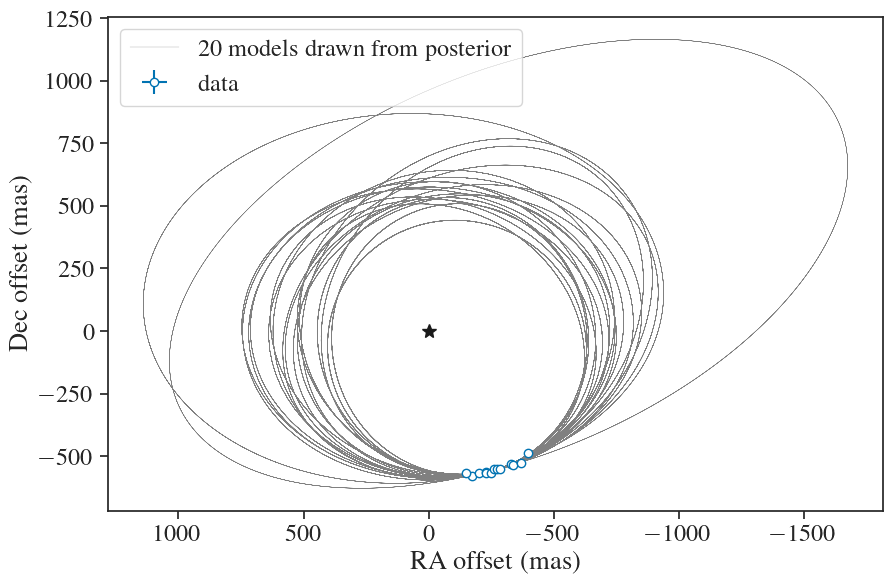

In [ ]:
plt.figure(figsize=(10,10))
plt.gca().invert_xaxis()
plt.gca().set_aspect(1.)
plt.xlabel("RA offset (mas)")
plt.ylabel("Dec offset (mas)")
plt.errorbar(ra_obs, dec_obs, fmt='o', xerr=ra_err, yerr=dec_err, zorder=1000, mfc='white', label='data')
plt.plot(0, 0, marker='*', color='k', markersize=10)
np.random.seed(123)
idxs = np.random.randint(0, len(ramodels), 20)
for idx in idxs[:-1]:
    plt.plot(ramodels[idx], decmodels[idx], color='gray', lw=0.2, zorder=-1000)
plt.plot(ramodels[idxs[-1]], decmodels[idxs[-1]], color='gray', lw=0.2, zorder=-1000, label='20 models drawn from posterior')
plt.legend(loc='best')
plt.savefig("models.png", dpi=500, bbox_inches="tight");